# Загрузка библиотек

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import pandas as pd
import sys
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


In [ ]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

In [ ]:
import wandb
wandb.login(key='8b1f2ae49570ea59dc8612ff434ca497d463d221')

In [7]:
pd.set_option('display.max_columns', None)

In [8]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [9]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Моделирование

## Baseline 1. Featurewiz + XGBoost

### Splashing

In [8]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost, splashing'
)

In [10]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.850746,0.876923,0.863636,65.000000
1,0.857143,0.827586,0.842105,58.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.853945,0.852255,0.852871,123.000000
weighted avg,0.853763,0.853659,0.853483,123.000000


#### Cross-Validation

In [11]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.52% (std: 1.86%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

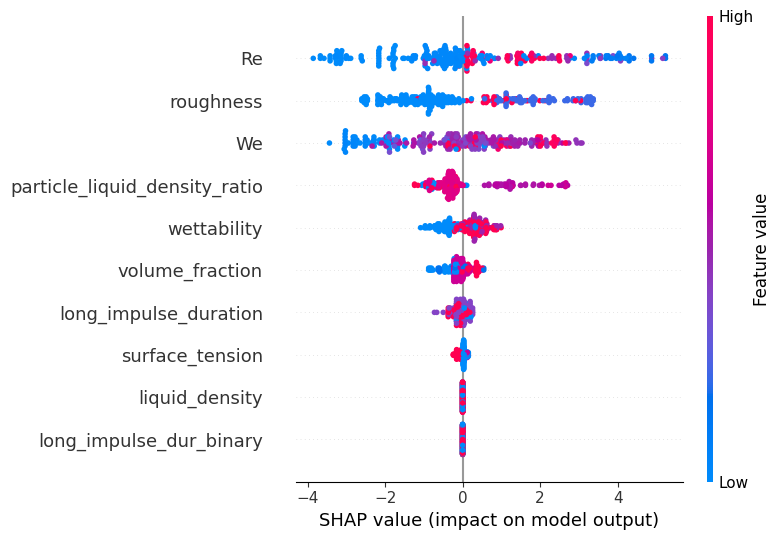

In [12]:
get_shap_interpretation(model, X_train)

#### Net impact

In [13]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost, net_impact'
)

In [15]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.886364,0.951220,0.917647,82.000000
1,0.885714,0.756098,0.815789,41.000000
accuracy,0.886179,0.886179,0.886179,0.886179
macro avg,0.886039,0.853659,0.866718,123.000000
weighted avg,0.886147,0.886179,0.883695,123.000000


In [16]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	73.09% (std: 8.03%)
F1 Test:	75.71% (std: 9.80%)


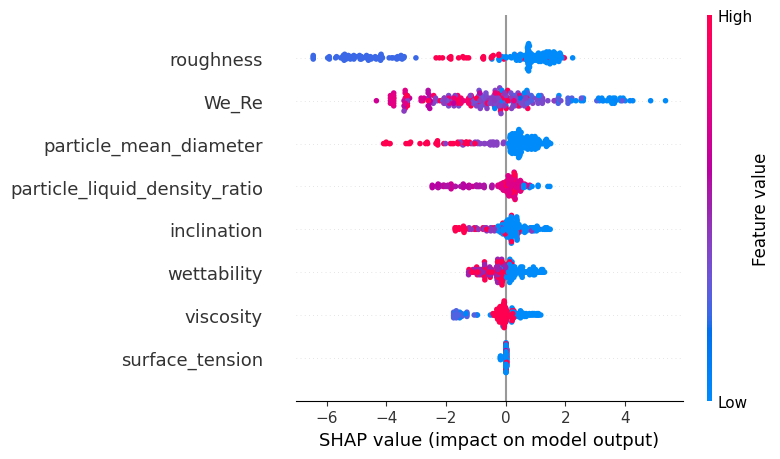

In [17]:
get_shap_interpretation(model, X_train)

## Baseline 2. Featurewiz + XGBoost + SMOTENC

### Splashing

In [18]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost + SMOTENC, splashing'
)

In [20]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [21]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.852941,0.892308,0.872180,65.000000
1,0.872727,0.827586,0.849558,58.000000
accuracy,0.861789,0.861789,0.861789,0.861789
macro avg,0.862834,0.859947,0.860869,123.000000
weighted avg,0.862271,0.861789,0.861513,123.000000


#### Cross-Validation

In [22]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.66% (std: 4.54%)
F1 Test:	79.55% (std: 5.16%)


#### SHAP interpretation

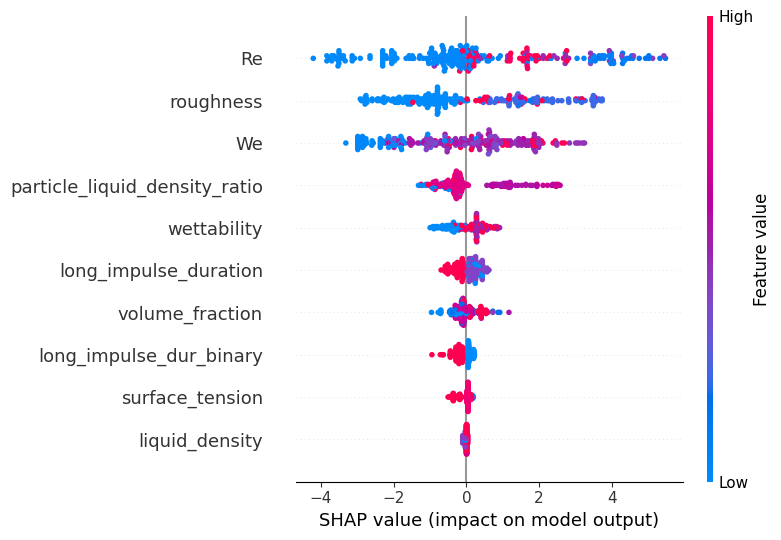

In [23]:
get_shap_interpretation(model, X_train)

### net_impact

In [24]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [25]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + XGBoost + SMOTENC, net_impact'
)

In [27]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.895349,0.939024,0.916667,82.000000
1,0.864865,0.780488,0.820513,41.000000
accuracy,0.886179,0.886179,0.886179,0.886179
macro avg,0.880107,0.859756,0.868590,123.000000
weighted avg,0.885188,0.886179,0.884615,123.000000


#### Cross-Validation

In [28]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.81% (std: 4.90%)
F1 Test:	75.71% (std: 9.80%)


#### SHAP interpretation

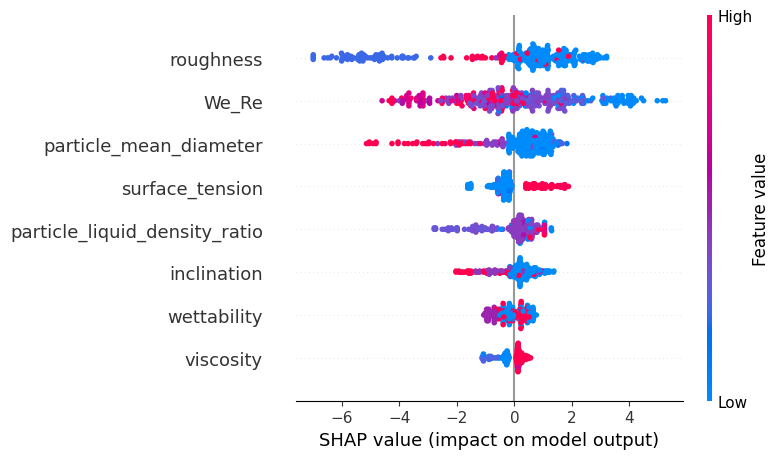

In [29]:
get_shap_interpretation(model, X_train)

# Модель на признаках из сообщения от 11 апреля в 10:09 в tg


Со Splashing и net_impact посложнее.

- По Re и We: возможны два датасета, в одном Re и We (два признака), в другом We_Re (один признак, либо ещё оставить We исходя из отсутствия мультиколлинеарности с We_Re)
- Второй важный признак тоже wettability_lyophobic
- Далее:
  - volume_fraction_binary, 
  - particle_liquid_density_ratio, 
  - particle_droplet_diameter_ratio (или particle_diameter_cat_large & _small),  
  - и возможно roughness_binary,

In [30]:
features = ['We', 'We_Re', 
'wettability_lyophobic', 'volume_fraction_binary', 
'particle_liquid_density_ratio', 'particle_droplet_diameter_ratio', 
'roughness_binary']

## Spalashing

In [31]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg, splashing'
)

In [33]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
get_classification_report(y_train, y_test, y_preds, y_preds_proba)
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


,precision,recall,f1-score,support
0,0.833333,0.846154,0.839695,65.000000
1,0.824561,0.810345,0.817391,58.000000
accuracy,0.829268,0.829268,0.829268,0.829268
macro avg,0.828947,0.828249,0.828543,123.000000
weighted avg,0.829197,0.829268,0.829178,123.000000


In [34]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	78.86% (std: 4.02%)
F1 Test:	70.23% (std: 5.12%)


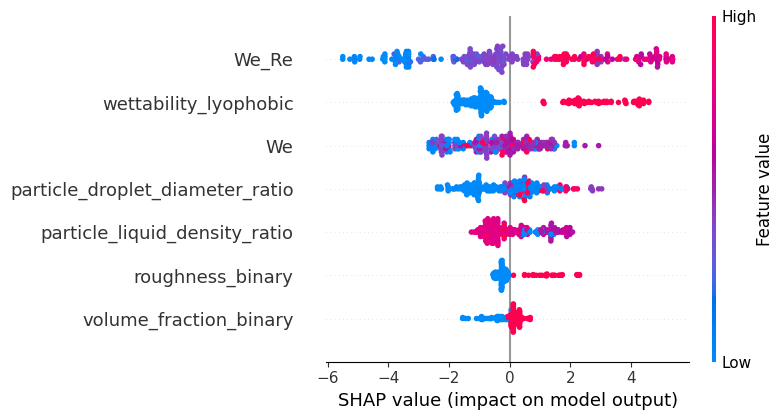

In [35]:
get_shap_interpretation(model, X_train)

## Net-impact

In [36]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg, net_impact'
)

In [38]:
model = XGBClassifier()
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.879518,0.890244,0.884848,82.000000
1,0.775000,0.756098,0.765432,41.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.827259,0.823171,0.825140,123.000000
weighted avg,0.844679,0.845528,0.845043,123.000000


In [39]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	63.79% (std: 3.56%)
F1 Test:	62.84% (std: 14.14%)


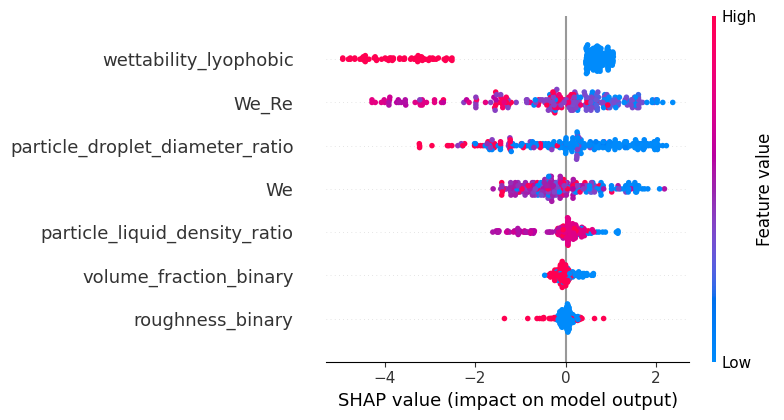

In [40]:
get_shap_interpretation(model, X_train)

# CatBoost на тех же признаках

## Splashing

In [41]:
cs = CreateSamples(df, train, test, features=features, target='splashing', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg + CatBoost, splashing'
)

In [43]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.859375,0.846154,0.852713,65.000000
1,0.830508,0.844828,0.837607,58.000000
accuracy,0.845528,0.845528,0.845528,0.845528
macro avg,0.844942,0.845491,0.845160,123.000000
weighted avg,0.845763,0.845528,0.845590,123.000000


In [44]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.30% (std: 5.14%)
F1 Test:	78.70% (std: 5.90%)


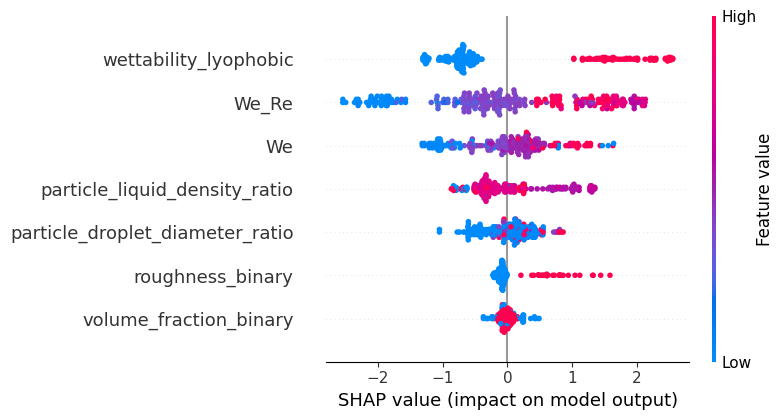

In [45]:
get_shap_interpretation(model, X_train)

## Net-impact

In [46]:
cs = CreateSamples(df, train, test, features=features, target='net_impact', dummies=True)
X_train, X_test, y_train, y_test = cs.get_samples()

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='Discussed features 11.04 tg + CatBoost, net_impact'
)

In [48]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.863636,0.926829,0.894118,82.000000
1,0.828571,0.707317,0.763158,41.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.846104,0.817073,0.828638,123.000000
weighted avg,0.851948,0.853659,0.850464,123.000000


In [49]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	73.54% (std: 4.36%)
F1 Test:	67.93% (std: 13.25%)


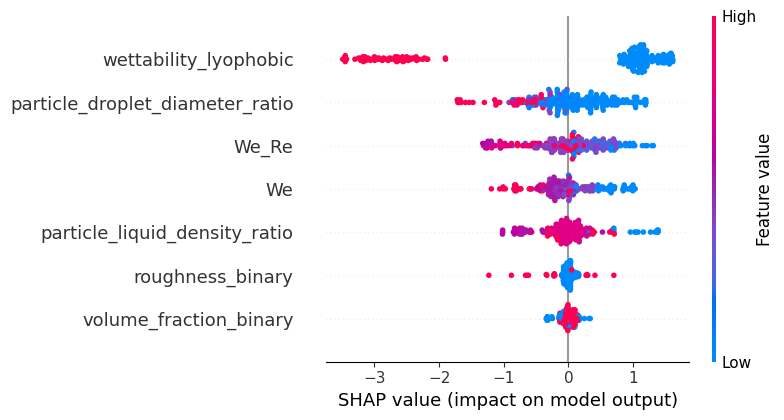

In [50]:
get_shap_interpretation(model, X_train)

## Baseline 2.1 Featurewiz + CatBoost + SMOTENC

### Splashing

In [51]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [52]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC, splashing'
)

In [54]:
model = CatBoostClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.861111,0.953846,0.905109,65.000000
1,0.941176,0.827586,0.880734,58.000000
accuracy,0.894309,0.894309,0.894309,0.894309
macro avg,0.901144,0.890716,0.892922,123.000000
weighted avg,0.898866,0.894309,0.893615,123.000000


#### Cross-Validation

In [55]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.57% (std: 2.51%)
F1 Test:	80.66% (std: 4.48%)


#### SHAP interpretation

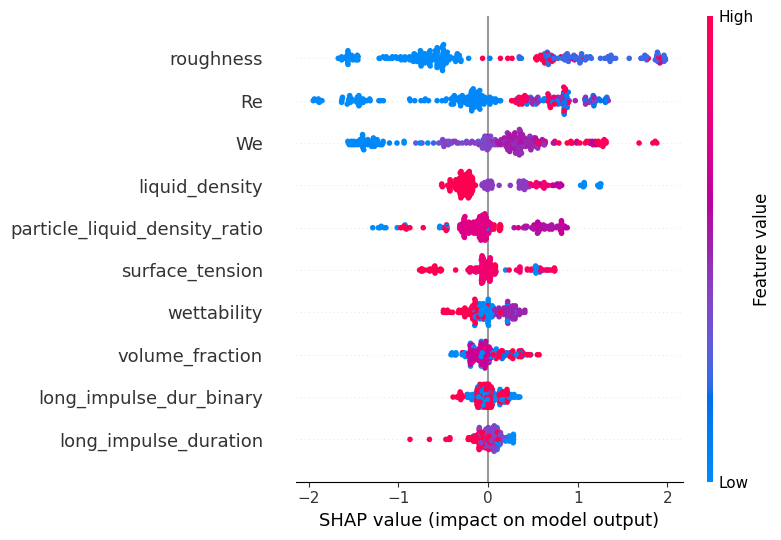

In [56]:
get_shap_interpretation(model, X_train)

### net_impact

In [57]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [58]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC, net_impact'
)

In [60]:
model = XGBClassifier(verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.895349,0.939024,0.916667,82.000000
1,0.864865,0.780488,0.820513,41.000000
accuracy,0.886179,0.886179,0.886179,0.886179
macro avg,0.880107,0.859756,0.868590,123.000000
weighted avg,0.885188,0.886179,0.884615,123.000000


#### Cross-Validation

In [61]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	86.81% (std: 4.90%)
F1 Test:	75.71% (std: 9.80%)


#### SHAP interpretation

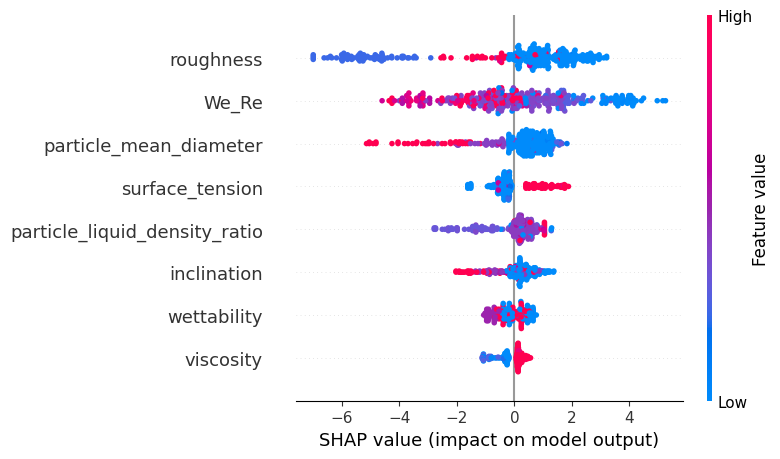

In [62]:
get_shap_interpretation(model, X_train)

Лучшая модель для splashing: featurewiz + CatBoost + SMOTENC

Лучшая модель для net_impact: featurewiz + CatBoost + SMOTENC

# Подбор гиперпараметров

## splashing: featurewiz + CatBoost + SMOTENC

In [18]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [19]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, splashing'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=7000, timeout=None)

In [22]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/splashing')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.861111,0.953846,0.905109,65.000000
1,0.941176,0.827586,0.880734,58.000000
accuracy,0.894309,0.894309,0.894309,0.894309
macro avg,0.901144,0.890716,0.892922,123.000000
weighted avg,0.898866,0.894309,0.893615,123.000000


In [23]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	84.50% (std: 3.16%)
F1 Test:	80.66% (std: 4.48%)


## net_impact: featurewiz + CatBoost + SMOTENC

In [24]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [25]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, net_impact'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=7000, timeout=None)

In [28]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/net_impact')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.900000,0.878049,0.888889,82.000000
1,0.767442,0.804878,0.785714,41.000000
accuracy,0.853659,0.853659,0.853659,0.853659
macro avg,0.833721,0.841463,0.837302,123.000000
weighted avg,0.855814,0.853659,0.854497,123.000000


In [29]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	81.42% (std: 5.52%)
F1 Test:	33.96% (std: 23.96%)


# featurewiz + Blending + XGBoost + LightGBM + CatBoost

## Splashing

In [17]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.3)

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [23]:
model = BlendingModels()
model.fit(X_train, X_val, y_train, y_val)
y_preds = model.predict(X_test)

In [21]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + Blending + XGBoost + LightGBM + CatBoost, splashing'
)

In [26]:
# y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba=None, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.800000,0.952381,0.869565,21.000000
1,0.916667,0.687500,0.785714,16.000000
accuracy,0.837838,0.837838,0.837838,0.837838
macro avg,0.858333,0.819940,0.827640,37.000000
weighted avg,0.850450,0.837838,0.833305,37.000000


## net_impact

In [27]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.3)

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 23)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [28]:
model = BlendingModels()
model.fit(X_train, X_val, y_train, y_val)
y_preds = model.predict(X_test)

In [29]:
smote_nc = SMOTENC(categorical_features=[7], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + Blending + XGBoost + LightGBM + CatBoost, net_impact'
)

In [31]:
# y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba=None, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.954545,0.777778,0.857143,27.000000
1,0.600000,0.900000,0.720000,10.000000
accuracy,0.810811,0.810811,0.810811,0.810811
macro avg,0.777273,0.838889,0.788571,37.000000
weighted avg,0.858722,0.810811,0.820077,37.000000
